# RegimeShift

Does an ML-predicted **volatility regime** improve a tactical SPY / TLT / GLD allocation?

**Target is volatility, not direction** — the model predicts whether SPY's realized vol over the *next 5 trading days* lands in the top third of its historical distribution. Nothing here forecasts returns.

Structure:
1. **Train/select** (first ~60%) — cross-validate 5 classifiers, pick one. All model choice happens here.
2. **Walk-forward middle** (next ~25%) — the winner is retrained on an expanding window and walked forward. Robustness checks run here.
3. **Final holdout** (last ~15%) — touched exactly once: one retrain, one prediction pass, final metrics. No decisions are made by looking at this chunk.

## Config

All structural constants live here. `EMBARGO = FWD_WINDOW = 5`: the target looks 5 trading days ahead, so any row within 5 days of a training-set boundary has a label that overlaps the evaluation period. Dropping the last 5 rows before every fit removes that leak. This applies to the CV folds, every walk-forward refit, and the final holdout fit.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix
from sklearn.inspection import permutation_importance

SEED = 42
RNG = np.random.default_rng(SEED)

FWD_WINDOW = 5            # forward horizon of the vol target (trading days)
EMBARGO = FWD_WINDOW      # rows dropped before every fit boundary
COST_BPS = 5              # one-way cost per unit of turnover
RETRAIN_EVERY = 21        # walk-forward refit cadence (~monthly)
N_SHUFFLES = 500          # shuffle-test permutations
TRAIN_FRAC, WF_FRAC = 0.60, 0.25   # holdout gets the remaining ~15%
ANN = np.sqrt(252)

ASSETS = ['SPY', 'TLT', 'GLD']
GROWTH    = pd.Series({'SPY': 0.70, 'TLT': 0.20, 'GLD': 0.10})
DEFENSIVE = pd.Series({'SPY': 0.25, 'TLT': 0.55, 'GLD': 0.20})
STATIC    = pd.Series({'SPY': 0.60, 'TLT': 0.30, 'GLD': 0.10})
EQW       = pd.Series({'SPY': 1/3,  'TLT': 1/3,  'GLD': 1/3})

## Data

SPY, TLT, GLD, ^VIX from yfinance (`auto_adjust=True`), 2007-01-01 to today, forward-filled then `dropna` so all series share one index.

`USE_SYNTHETIC = True` replaces the download with a simulated 2-state Markov volatility-regime market (calm vs. turbulent daily vol, VIX proxy derived from realized vol). The entire pipeline below was validated end-to-end on this synthetic data before touching real prices — flip the flag to reproduce that check offline.

In [ ]:
USE_SYNTHETIC = False

if USE_SYNTHETIC:
    dates = pd.bdate_range('2007-01-01', pd.Timestamp.today())
    n = len(dates)
    state = np.zeros(n, dtype=int)
    for t in range(1, n):
        p_switch = 0.02 if state[t-1] == 0 else 0.05
        state[t] = state[t-1] ^ (RNG.random() < p_switch)
    sig = np.where(state == 1, 0.025, 0.008)
    spy_r = RNG.normal(0.0005 - 0.0012 * state, sig)
    tlt_r = RNG.normal(0.0002, 0.006, n) - 0.30 * state * spy_r
    gld_r = RNG.normal(0.0003, 0.010, n) + 0.10 * state * np.abs(spy_r)
    rv20 = pd.Series(spy_r, index=dates).rolling(20).std().bfill() * np.sqrt(252)
    vix = (100 * rv20 + RNG.normal(0, 1.5, n)).clip(lower=9)
    px = pd.DataFrame({
        'SPY': 100 * np.cumprod(1 + spy_r),
        'TLT': 100 * np.cumprod(1 + tlt_r),
        'GLD': 100 * np.cumprod(1 + gld_r),
        'VIX': vix,
    }, index=dates)
else:
    import yfinance as yf
    raw = yf.download(['SPY', 'TLT', 'GLD', '^VIX'], start='2007-01-01',
                      auto_adjust=True, progress=False)['Close']
    px = raw.rename(columns={'^VIX': 'VIX'})

px = px.ffill().dropna()
print(px.shape)
px.tail(3)

(4941, 4)


Ticker,GLD,SPY,TLT,VIX
Date,,,,
2026-08-19,413.839996,769.059998,83.019997,14.89
2026-08-20,415.260010,762.599976,82.339996,16.01
2026-08-21,423.359985,765.719971,82.050003,15.13


## Features and target

Four features, all strictly backward-looking as of each row's date: 20-day realized SPY vol (annualized), VIX level, 60-day SPY–TLT return correlation, 21-day SPY momentum.

**Target:** 1 if realized SPY vol over the *next 5 trading days* exceeds the top-third (66.7th percentile) threshold of history — this is a **volatility** label, not a direction label. The tercile threshold is computed on an *expanding* window of past 5-day realized vol, so the threshold at date *t* only uses information available at *t* (a full-sample tercile would leak the future distribution into early labels).

In [ ]:
rets = px[ASSETS].pct_change()

feat = pd.DataFrame(index=px.index)
feat['vol20']  = rets['SPY'].rolling(20).std() * ANN
feat['vix']    = px['VIX']
feat['corr60'] = rets['SPY'].rolling(60).corr(rets['TLT'])
feat['mom21']  = px['SPY'].pct_change(21)

vol5_past = rets['SPY'].rolling(FWD_WINDOW).std() * ANN
vol5_fwd  = vol5_past.shift(-FWD_WINDOW)
thresh    = vol5_past.expanding(min_periods=252).quantile(2/3)

data = feat.copy()
data['vol5_past'] = vol5_past
data['thresh']    = thresh
data['y']         = (vol5_fwd > thresh).astype(float)
data = data.dropna()

FEATURES = ['vol20', 'vix', 'corr60', 'mom21']
X, y = data[FEATURES], data['y'].astype(int)
print(f"rows: {len(data)}, positive rate: {y.mean():.3f}")

rows: 4685, positive rate: 0.258


## Chronological three-way split

First ~60% → train/select. Next ~25% → walk-forward middle. Last ~15% → final holdout, touched exactly once. Date ranges printed below so the split is auditable.

In [ ]:
n = len(data)
i1 = int(n * TRAIN_FRAC)
i2 = int(n * (TRAIN_FRAC + WF_FRAC))

idx_train = data.index[:i1]
idx_wf    = data.index[i1:i2]
idx_hold  = data.index[i2:]

for name, idx in [('TRAIN/SELECT', idx_train), ('WALK-FORWARD', idx_wf), ('FINAL HOLDOUT', idx_hold)]:
    print(f"{name:14s} {idx[0].date()} -> {idx[-1].date()}  ({len(idx)} rows)")

TRAIN/SELECT   2008-01-09 -> 2019-03-11  (2811 rows)
WALK-FORWARD   2019-03-12 -> 2023-11-01  (1171 rows)
FINAL HOLDOUT  2023-11-02 -> 2026-08-21  (703 rows)


## Model selection — TRAIN/SELECT chunk only

Five classifiers compared by mean AUC under `TimeSeriesSplit(n_splits=5)`, using **only the first ~60% of data**. The last `EMBARGO` rows of each fold's training slice are dropped (labels there overlap the test fold's dates). The winner is fixed here and never revisited.

In [ ]:
def make_models():
    return {
        'LogisticRegression': Pipeline([('sc', StandardScaler()),
                                        ('m', LogisticRegression(max_iter=2000, random_state=SEED))]),
        'DecisionTree':       Pipeline([('sc', StandardScaler()),
                                        ('m', DecisionTreeClassifier(max_depth=4, random_state=SEED))]),
        'RandomForest':       Pipeline([('sc', StandardScaler()),
                                        ('m', RandomForestClassifier(n_estimators=200, max_depth=6,
                                                                     random_state=SEED, n_jobs=-1))]),
        'KNN':                Pipeline([('sc', StandardScaler()),
                                        ('m', KNeighborsClassifier(n_neighbors=25))]),
        'SVM':                Pipeline([('sc', StandardScaler()),
                                        ('m', SVC(kernel='rbf', random_state=SEED))]),
    }

def auc_score(model, Xte, yte):
    if hasattr(model, 'predict_proba'):
        s = model.predict_proba(Xte)[:, 1]
    else:
        s = model.decision_function(Xte)
    return roc_auc_score(yte, s)

Xtr, ytr = X.loc[idx_train], y.loc[idx_train]
tscv = TimeSeriesSplit(n_splits=5)
cv_results = {}
for name, model in make_models().items():
    aucs = []
    for tr, te in tscv.split(Xtr):
        tr = tr[:-EMBARGO]
        m = clone(model).fit(Xtr.iloc[tr], ytr.iloc[tr])
        aucs.append(auc_score(m, Xtr.iloc[te], ytr.iloc[te]))
    cv_results[name] = np.mean(aucs)

cv_table = pd.Series(cv_results).sort_values(ascending=False).rename('mean CV AUC')
print(cv_table.round(4).to_string())
WINNER = cv_table.index[0]
print(f"\nWinner (fixed from here on): {WINNER}")

LogisticRegression    0.8613
KNN                   0.7904
RandomForest          0.7667
DecisionTree          0.6820
SVM                   0.6645

Winner (fixed from here on): LogisticRegression


## Walk-forward through the middle chunk

The winning model is refit every 21 rows (~monthly) on an **expanding window** starting from the beginning of the data, minus the 5-row embargo before each refit boundary, then predicts the next 21-row block. No parameters change during the walk.

In [ ]:
def model_scores(m, Xb):
    if hasattr(m, 'predict_proba'):
        return m.predict_proba(Xb)[:, 1]
    return m.decision_function(Xb)

preds_wf  = pd.Series(index=idx_wf, dtype=float)
scores_wf = pd.Series(index=idx_wf, dtype=float)
for start in range(i1, i2, RETRAIN_EVERY):
    end = min(start + RETRAIN_EVERY, i2)
    m = clone(make_models()[WINNER]).fit(X.iloc[:start - EMBARGO], y.iloc[:start - EMBARGO])
    preds_wf.iloc[start - i1:end - i1]  = m.predict(X.iloc[start:end])
    scores_wf.iloc[start - i1:end - i1] = model_scores(m, X.iloc[start:end])

print(f"all rows predicted: {preds_wf.notna().all()}, class-1 rate: {preds_wf.mean():.3f}")

all rows predicted: True, class-1 rate: 0.211


## Final holdout — one shot

Retrain the winner once on everything before the holdout (train/select + walk-forward middle, minus the embargo), predict across the entire holdout in a single pass. This cell is the only place the holdout features are consumed; nothing upstream was chosen using this chunk.

In [ ]:
m_final = clone(make_models()[WINNER]).fit(X.iloc[:i2 - EMBARGO], y.iloc[:i2 - EMBARGO])
preds_hold  = pd.Series(m_final.predict(X.loc[idx_hold]), index=idx_hold, dtype=float)
scores_hold = pd.Series(model_scores(m_final, X.loc[idx_hold]), index=idx_hold)
print(f"holdout predictions: {len(preds_hold)} rows, class-1 rate {preds_hold.mean():.3f}")

holdout predictions: 703 rows, class-1 rate 0.094


## Table 1 — Regime-prediction performance

Predictive quality is reported separately from economic value: a classifier can rank regimes well and still fail to make money under a given allocation rule, and conflating the two hides which one failed. AUC here uses the model's continuous scores (probabilities or decision-function margins), not the 0/1 predictions — binary predictions throw away the ranking information AUC is meant to measure. Precision, recall, the confusion matrix, and the positive-class base rate give the full picture of what the thresholded signal actually feeds the strategy.

In [ ]:
def diagnostics(y_true, preds, scores):
    return {
        'AUC (scores)':  roc_auc_score(y_true, scores),
        'Precision':     precision_score(y_true, preds, zero_division=0),
        'Recall':        recall_score(y_true, preds, zero_division=0),
        'Base rate':     y_true.mean(),
        'Pred. rate':    preds.mean(),
    }

table1 = pd.DataFrame({
    'Walk-forward':  diagnostics(y.loc[idx_wf],   preds_wf,   scores_wf),
    'Final holdout': diagnostics(y.loc[idx_hold], preds_hold, scores_hold),
}).T

print("=== TABLE 1: REGIME-PREDICTION PERFORMANCE ===")
print(table1.round(4).to_string())

for label, yt, pr in [('Walk-forward', y.loc[idx_wf], preds_wf),
                      ('Final holdout', y.loc[idx_hold], preds_hold)]:
    cm = confusion_matrix(yt, pr)
    print(f"\n{label} confusion matrix (rows=actual 0/1, cols=predicted 0/1):")
    print(pd.DataFrame(cm, index=['actual 0', 'actual 1'],
                       columns=['pred 0', 'pred 1']).to_string())

=== TABLE 1: REGIME-PREDICTION PERFORMANCE ===
               AUC (scores)  Precision  Recall  Base rate  Pred. rate
Walk-forward         0.8022     0.8340  0.4469     0.3937      0.2109
Final holdout        0.7556     0.6667  0.2953     0.2119      0.0939

Walk-forward confusion matrix (rows=actual 0/1, cols=predicted 0/1):
          pred 0  pred 1
actual 0     669      41
actual 1     255     206

Final holdout confusion matrix (rows=actual 0/1, cols=predicted 0/1):
          pred 0  pred 1
actual 0     532      22
actual 1     105      44


## Table 2 — Portfolio performance: strategies and benchmarks

Yesterday's prediction sets today's weights (`shift(1)`), so the first day of each chunk is dropped. Weights: predicted 1 → 25/55/20 defensive; predicted 0 → 70/20/10 growth. The portfolio rebalances **only when the target changes** (and on monthly dates for the static baselines); between rebalances weights drift with returns. Each rebalance pays `COST_BPS` per unit of one-way turnover, applied to all rebalancing strategies alike; the initial position is free for everyone. Total turnover is reported as its own number.

The **central benchmark is the no-ML vol rule**: if 20d realized SPY vol is above its own expanding historical median, hold the defensive weights, else growth — same weight pairs, same signal lag, same costs. It isolates the question that matters: does the classifier add value *beyond obvious volatility persistence*? Beating buy-and-hold or a static mix is not evidence of ML skill; beating this rule would be. The remaining baselines over the same periods: static 60/30/10 monthly, equal-weight monthly, buy-and-hold SPY.

In [ ]:
def backtest(chunk_idx, target_w, reb_mask):
    r = rets.loc[chunk_idx].to_numpy()
    tw = target_w.loc[chunk_idx].to_numpy()
    rb = reb_mask.loc[chunk_idx].to_numpy()
    w = tw[0].copy()
    total_turn, out = 0.0, np.empty(len(chunk_idx))
    for i in range(len(chunk_idx)):
        cost = 0.0
        if rb[i] and i > 0:
            turn = np.abs(tw[i] - w).sum()
            total_turn += turn
            cost = turn * COST_BPS / 1e4
            w = tw[i].copy()
        gross = float(w @ r[i])
        out[i] = gross - cost
        w = w * (1 + r[i])
        w = w / w.sum()
    return pd.Series(out, index=chunk_idx), total_turn

def weights_from_signal(sig):
    return pd.DataFrame([DEFENSIVE if s == 1 else GROWTH for s in sig], index=sig.index)

def signal_strategy(sig_raw, chunk_idx):
    sig = sig_raw.reindex(chunk_idx).shift(1).dropna().astype(int)
    tw = weights_from_signal(sig)
    reb = sig.ne(sig.shift(1))
    return backtest(sig.index, tw, reb)

def monthly_strategy(weights, chunk_idx):
    idx = chunk_idx[1:]
    tw = pd.DataFrame([weights] * len(idx), index=idx)
    months = idx.to_series().dt.to_period('M')
    reb = months.ne(months.shift(1)); reb.iloc[0] = False
    return backtest(idx, tw, reb)

def spy_only(chunk_idx):
    return rets['SPY'].loc[chunk_idx[1:]], 0.0

vol_rule_sig = (feat['vol20'] > feat['vol20'].expanding(252).median()).astype(int)

def metrics(r, turnover):
    curve = (1 + r).cumprod()
    cagr = curve.iloc[-1] ** (252 / len(r)) - 1
    sharpe = r.mean() / r.std() * ANN if r.std() > 0 else np.nan
    mdd = (curve / curve.cummax() - 1).min()
    return {'CAGR': cagr, 'Sharpe': sharpe, 'MaxDD': mdd, 'Turnover': turnover}

def run_chunk(chunk_idx, ml_preds):
    runs = {
        'ML regime':        signal_strategy(ml_preds, chunk_idx),
        'Vol rule (no ML)': signal_strategy(vol_rule_sig, chunk_idx),
        'Static 60/30/10':  monthly_strategy(STATIC, chunk_idx),
        'Equal weight':     monthly_strategy(EQW, chunk_idx),
        'SPY buy&hold':     spy_only(chunk_idx),
    }
    table = pd.DataFrame({k: metrics(r, tn) for k, (r, tn) in runs.items()}).T
    curves = pd.DataFrame({k: (1 + r).cumprod() for k, (r, _) in runs.items()})
    return runs, table, curves

runs_wf, table_wf, curves_wf = run_chunk(idx_wf, preds_wf)
runs_hold, table_hold, curves_hold = run_chunk(idx_hold, preds_hold)

pd.set_option('display.float_format', lambda v: f'{v: .4f}')
print("=== TABLE 2: PORTFOLIO PERFORMANCE — WALK-FORWARD MIDDLE ===")
print(table_wf.to_string())
print(f"\nML strategy total turnover (walk-forward): {table_wf.loc['ML regime','Turnover']:.2f}x")
print("\n=== TABLE 2: PORTFOLIO PERFORMANCE — FINAL HOLDOUT ===")
print(table_hold.to_string())
print(f"\nML strategy total turnover (holdout): {table_hold.loc['ML regime','Turnover']:.2f}x")

=== TABLE 2: PORTFOLIO PERFORMANCE — WALK-FORWARD MIDDLE ===
                    CAGR  Sharpe   MaxDD  Turnover
ML regime         0.0284  0.2906 -0.3188   70.0794
Vol rule (no ML)  0.0393  0.3950 -0.2781   24.2580
Static 60/30/10   0.0633  0.5325 -0.2532    1.3231
Equal weight      0.0532  0.5288 -0.2305    1.4300
SPY buy&hold      0.1116  0.6005 -0.3372    0.0000

ML strategy total turnover (walk-forward): 70.08x

=== TABLE 2: PORTFOLIO PERFORMANCE — FINAL HOLDOUT ===
                    CAGR  Sharpe   MaxDD  Turnover
ML regime         0.1806  1.6123 -0.1223   18.0036
Vol rule (no ML)  0.1720  1.6163 -0.0774   29.6989
Static 60/30/10   0.1867  1.6001 -0.1115    0.5963
Equal weight      0.2041  1.7228 -0.0944    0.8413
SPY buy&hold      0.2444  1.4908 -0.1876    0.0000

ML strategy total turnover (holdout): 18.00x


## Equity curves

All five series, walk-forward chunk and holdout chunk plotted separately (each rebased to 1.0 at its own chunk start — do not read them as one continuous curve).

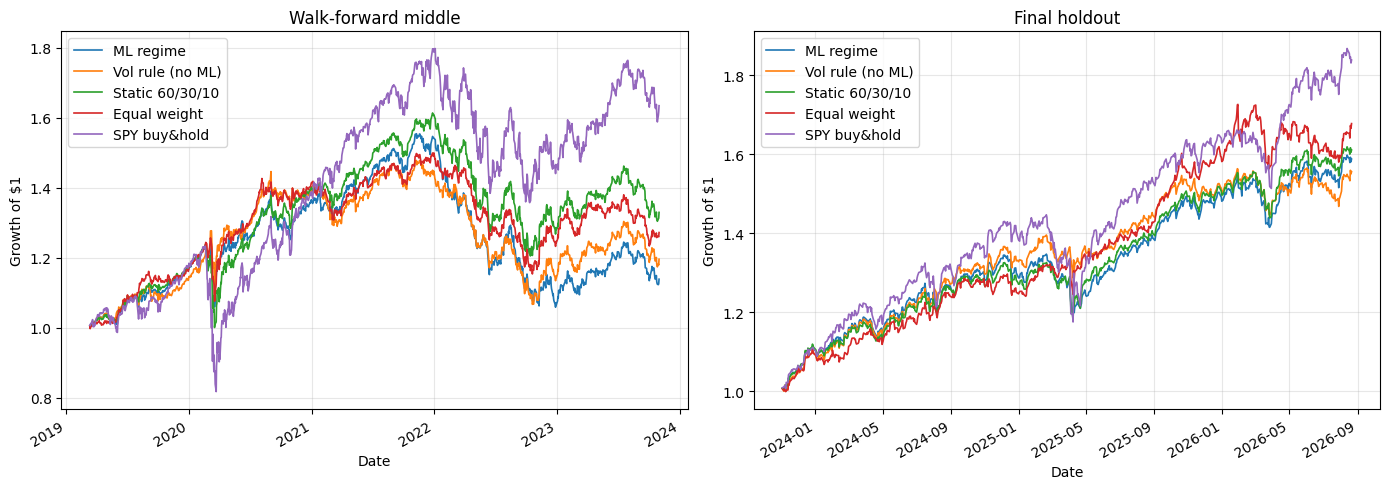

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, curves, title in [(axes[0], curves_wf, 'Walk-forward middle'),
                          (axes[1], curves_hold, 'Final holdout')]:
    curves.plot(ax=ax, linewidth=1.2)
    ax.set_title(title); ax.set_ylabel('Growth of $1'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Feature importance — final model

Coefficients (linear models) or impurity importances (trees) when available; otherwise permutation importance computed on the **training** data (never on the holdout, which would count as another look).

vol20     0.3805
vix       1.4555
corr60    0.3050
mom21    -0.5184


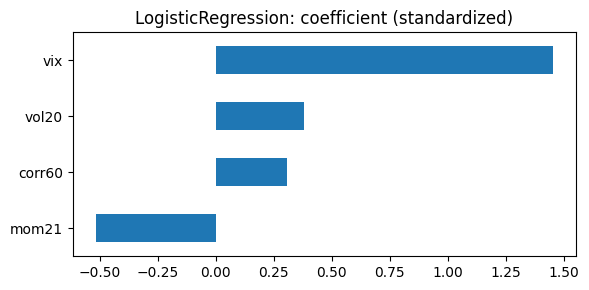

In [ ]:
inner = m_final.named_steps['m']
if hasattr(inner, 'coef_'):
    imp = pd.Series(inner.coef_.ravel(), index=FEATURES, name='coefficient (standardized)')
elif hasattr(inner, 'feature_importances_'):
    imp = pd.Series(inner.feature_importances_, index=FEATURES, name='impurity importance')
else:
    pi = permutation_importance(m_final, X.iloc[:i2 - EMBARGO], y.iloc[:i2 - EMBARGO],
                                n_repeats=10, random_state=SEED, scoring='roc_auc')
    imp = pd.Series(pi.importances_mean, index=FEATURES, name='permutation importance (train)')

print(imp.round(4).to_string())
imp.sort_values().plot.barh(figsize=(6, 3), title=f'{WINNER}: {imp.name}')
plt.tight_layout(); plt.show()

## Robustness checks (walk-forward chunk only)

**Shuffle test** — permute the prediction series 500×, run the identical allocation rule, and compare the real Sharpe against the shuffled distribution. This is a robustness check on whether the signal's *timing* carries information, not a search for significance: the empirical p-value is reported as-is, whatever it says.

**Lagged-signal test** — replace the model with "was 5-day realized vol above its threshold *yesterday*?" (the realized regime, no forecasting). If this does about as well as the ML strategy, the model is only capturing vol persistence, not adding forecasting skill.

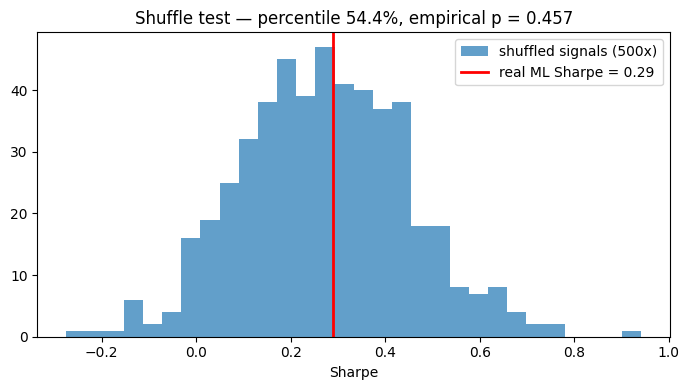

Real ML Sharpe (walk-forward):        0.291
Lagged realized-regime Sharpe:        0.345
Shuffled-signal Sharpe mean +/- std:  0.273 +/- 0.178
Empirical p-value (shuffle test):     0.4571  (real Sharpe at the 54.4th percentile of 500 shuffles)


In [ ]:
real_sharpe = table_wf.loc['ML regime', 'Sharpe']

shuffled = []
for _ in range(N_SHUFFLES):
    perm = pd.Series(RNG.permutation(preds_wf.values), index=idx_wf)
    r, _t = signal_strategy(perm, idx_wf)
    shuffled.append(r.mean() / r.std() * ANN)
shuffled = np.array(shuffled)
pct = (shuffled < real_sharpe).mean() * 100
p_emp = (1 + (shuffled >= real_sharpe).sum()) / (N_SHUFFLES + 1)

plt.figure(figsize=(7, 4))
plt.hist(shuffled, bins=30, alpha=0.7, label=f'shuffled signals ({N_SHUFFLES}x)')
plt.axvline(real_sharpe, color='red', linewidth=2, label=f'real ML Sharpe = {real_sharpe:.2f}')
plt.title(f'Shuffle test — percentile {pct:.1f}%, empirical p = {p_emp:.3f}')
plt.xlabel('Sharpe'); plt.legend(); plt.tight_layout(); plt.show()

lag_sig = (data['vol5_past'] > data['thresh']).astype(int)
r_lag, turn_lag = signal_strategy(lag_sig, idx_wf)
lag = metrics(r_lag, turn_lag)
print(f"Real ML Sharpe (walk-forward):        {real_sharpe:.3f}")
print(f"Lagged realized-regime Sharpe:        {lag['Sharpe']:.3f}")
print(f"Shuffled-signal Sharpe mean +/- std:  {shuffled.mean():.3f} +/- {shuffled.std():.3f}")
print(f"Empirical p-value (shuffle test):     {p_emp:.4f}  "
      f"(real Sharpe at the {pct:.1f}th percentile of {N_SHUFFLES} shuffles)")